# MNIST Inference on AUP-ZU3
Loads pre-trained weights and runs inference on PS.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Load Weights

In [2]:
W1 = np.load('w1.npy')  # (784, 128)
b1 = np.load('b1.npy')  # (128,)
W2 = np.load('w2.npy')  # (128, 10)
b2 = np.load('b2.npy')  # (10,)

print('W1:', W1.shape, '  b1:', b1.shape)
print('W2:', W2.shape, '  b2:', b2.shape)

W1: (784, 128)   b1: (128,)
W2: (128, 10)   b2: (10,)


## 2. Load MNIST Test Data

In [3]:
def load_idx_images(path):
    with open(path, 'rb') as f:
        f.read(4)
        n     = int.from_bytes(f.read(4), 'big')
        rows  = int.from_bytes(f.read(4), 'big')
        cols  = int.from_bytes(f.read(4), 'big')
        data  = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(n, rows, cols)

def load_idx_labels(path):
    with open(path, 'rb') as f:
        f.read(4)
        n    = int.from_bytes(f.read(4), 'big')
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data

# Update these paths to wherever you placed the MNIST files on the board
x_test = load_idx_images('t10k-images.idx3-ubyte')
y_test = load_idx_labels('t10k-labels.idx1-ubyte')

# Normalize and flatten
x_test_flat = x_test.reshape(-1, 784).astype(np.float32) / 255.0

print(f'Test images: {x_test.shape}  |  Test labels: {y_test.shape}')

Test images: (10000, 28, 28)  |  Test labels: (10000,)


## 3. Inference Functions

In [5]:
# Rectified Linear Unit (ReLU) activation function to zero out negatives
def relu(x):
    return np.maximum(0, x)

# Softmax function to turn the final layer's outputs into probabilities for each digit
def softmax(x):
    e = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e / np.sum(e, axis=-1, keepdims=True)

# Forward pass function to pass input through the network layers (apply ReLU after the first layer and softmax at the end)
def forward_pass(x_input):
    a1 = relu(x_input @ W1 + b1) # Layer 1 multiply by weights, add bias, apply ReLU
    return softmax(a1 @ W2 + b2) # Layer 2 multiply by weights, add bias, apply softmax

## 4. Predictions

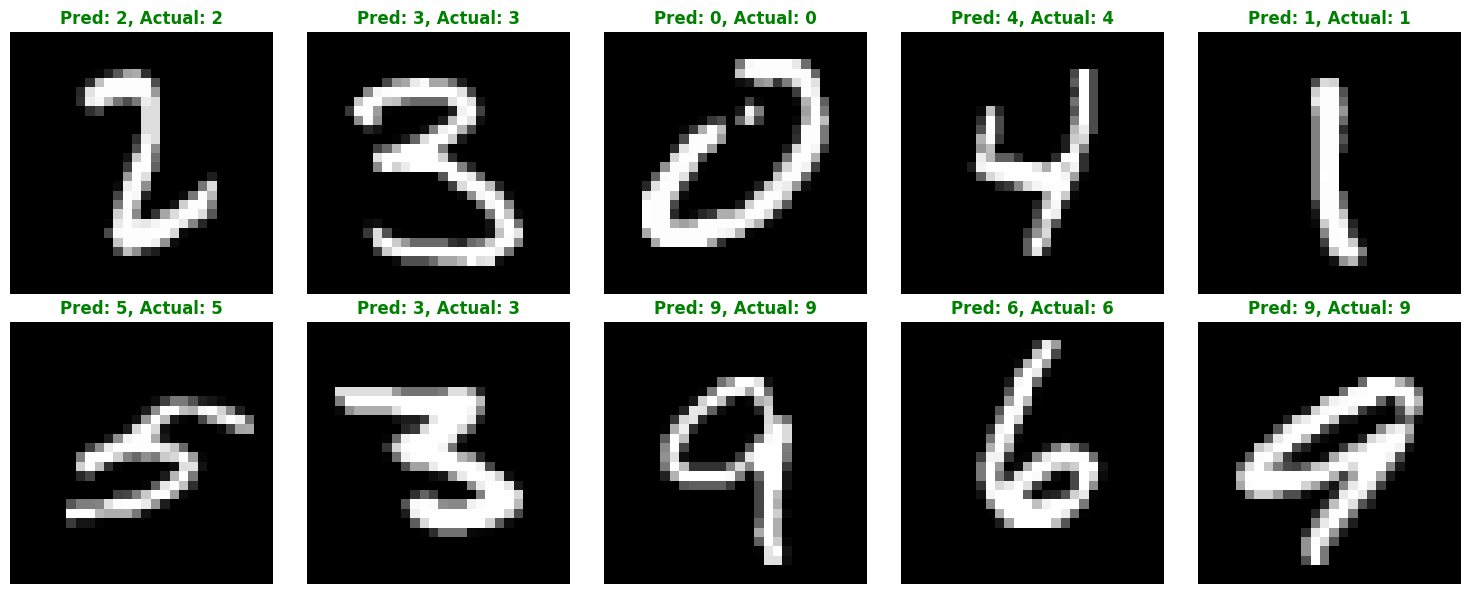


Prediction Summary:
Correctly predicted: 10 / 10

Timing:
  Total (10 images): 2.4051 ms
  Per image: 0.2405 ms


In [ ]:
import time

# Randomly select 30 test images for prediction and timing
num_samples = 30
indices = np.random.choice(len(x_test_flat), num_samples, replace=False)

# Time the full forward pass on the selected test images
t0 = time.perf_counter()
predictions = forward_pass(x_test_flat[indices])
t1 = time.perf_counter()

# Get predicted labels and calculate timing
predicted_labels = np.argmax(predictions, axis=1)
total_ms = (t1 - t0) * 1000
per_image_ms = total_ms / num_samples

# Create a grid of images with predicted vs actual labels
fig, axes = plt.subplots(6, 5, figsize=(15, 6))
axes = axes.flatten()

# Show the images with predicted and actual labels in the title, colored by correctness
for idx, ax in enumerate(axes):
    image = x_test[indices[idx]].reshape(28, 28)
    ax.imshow(image, cmap='gray')

    predicted = predicted_labels[idx]
    actual    = y_test[indices[idx]]
    color     = 'green' if predicted == actual else 'red'

    ax.set_title(f'Pred: {predicted}, Actual: {actual}', color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Print summary of predictions and timing
print('\nPrediction Summary:')
print(f'Correctly predicted: {np.sum(predicted_labels == y_test[indices])} / {num_samples}')
print(f'\nTiming:')
print(f'  Total ({num_samples} images): {total_ms:.4f} ms')
print(f'  Per image: {per_image_ms:.4f} ms')

## 5. Full Test Set Accuracy

In [6]:
all_predictions = np.argmax(forward_pass(x_test_flat), axis=1)
accuracy = np.sum(all_predictions == y_test) / len(y_test)
print(f'Test accuracy: {accuracy:.2%}')

Test accuracy: 97.81%
